In [6]:
# Customer Churn Prediction Using ANN

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [1]:
import kagglehub
import os

path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

100%|██████████| 262k/262k [00:00<00:00, 14.6MB/s]

Extracting files...


In [14]:
# Load dataset (Telco Customer Churn CSV)
df = pd.read_csv(os.path.join(path, "Churn_Modelling.csv"))

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [9]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [15]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'])

In [17]:
df.sample(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
5210,551,35,7,129717.30,2,0,0,86937.20,0,True,False,False,False,True
7096,559,38,3,145874.35,1,1,0,56311.39,1,False,False,True,False,True
298,511,58,0,149117.31,1,1,1,162599.51,0,True,False,False,False,True


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['Exited'], axis=1), df['Exited'], test_size=0.2, random_state=42
)

In [61]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
9254,686,32,6,0.00,2,1,1,179093.26,True,False,False,False,True
1561,632,42,4,119624.60,2,1,1,195978.86,False,True,False,False,True
1670,559,24,3,114739.92,1,1,0,85891.02,False,False,True,False,True
6087,561,27,9,135637.00,1,1,0,153080.40,True,False,False,True,False
6669,517,56,9,142147.32,1,0,0,39488.04,True,False,False,False,True


In [20]:
X_train.shape

(8000, 13)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_scaled.shape

(8000, 13)

In [27]:
# dependencies for ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [42]:
# ANN architecture
model = Sequential()

model.add(Dense(5, activation='relu', input_dim=13))    # hidden layer1
model.add(Dense(5, activation='relu'))    # hidden layer2
model.add(Dense(1, activation='sigmoid'))   # output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 5)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106 (424.00 B)

 Trainable params: 106 (424.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [47]:
history = model.fit(X_train_scaled, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8305 - loss: 0.4121 - val_accuracy: 0.8350 - val_loss: 0.4063
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8305 - loss: 0.4103 - val_accuracy: 0.8375 - val_loss: 0.4050
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8311 - loss: 0.4089 - val_accuracy: 0.8388 - val_loss: 0.4038
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8298 - loss: 0.4075 - val_accuracy: 0.8400 - val_loss: 0.4034
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8306 - loss: 0.4063 - val_accuracy: 0.8388 - val_loss: 0.4019
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8311 - loss: 0.4046 - val_accuracy: 0.8375 - val_loss: 0.4006
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8317 - loss: 0.4033 - val_accuracy: 0.8388 - val_loss: 0.4006
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8317 - loss: 0.4020 - val_accuracy: 0

In [48]:
model.layers[0].get_weights()

[array([[ 0.0644902 , -0.11927259,  0.05166773, -0.03537798, -0.01772665],
        [-0.31883755,  0.8861704 , -1.1203336 ,  0.32908976, -0.7430134 ],
        [ 0.03563067, -0.05060906, -0.02106683, -0.07774153, -0.11965648],
        [-0.56728756, -0.50563455, -0.03497224, -0.42806184, -0.26852313],
        [-0.19814119, -0.49996975, -0.11166397, -0.9208901 , -0.459205  ],
        [ 0.11599081,  0.22853561, -0.02681154,  0.05942906,  0.01726296],
        [-0.1141304 ,  0.68844116, -0.03630465, -0.45470175, -0.1095327 ],
        [-0.2096386 , -0.15965335,  0.11784128,  0.00544949,  0.02606528],
        [-0.26149344,  0.03607385,  0.34073627, -0.22500558, -0.20495398],
        [-0.53071743, -0.20126133,  0.25872904,  0.08426139, -0.21262735],
        [-0.17911239,  0.27130926,  0.23898168, -0.19819194, -0.2817879 ],
        [-0.66050494, -0.24920931, -0.7491376 ,  0.31821144,  0.8264759 ],
        [-0.0505458 , -0.51618165,  0.24070507,  0.01804972, -0.58010244]],
       dtype=float32),
 

In [49]:
model.layers[1].get_weights()

[array([[-0.33114976,  0.43540975,  0.81727046,  0.6792957 ,  0.05765408],
        [ 0.45659792,  0.868766  , -0.5057357 ,  0.48700896,  0.06074161],
        [ 0.7767495 ,  0.2012372 ,  0.00272131, -0.18591188, -1.2007042 ],
        [-0.10723102, -0.4508295 , -0.6809524 ,  0.8310934 , -0.32750404],
        [-0.81540114, -0.2692318 ,  0.9488519 ,  0.08765794,  0.76587397]],
       dtype=float32),
 array([ 0.05213858,  0.11330686,  0.24416123,  0.27394128, -0.08558861],
       dtype=float32)]

In [50]:
y_hat = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [51]:
y_pred = np.where(y_hat > 0.5, 1, 0)

In [52]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.843


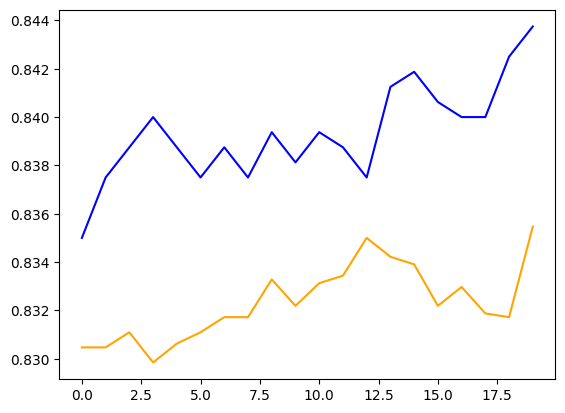

In [57]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], 'orange')
plt.plot(history.history['val_accuracy'], 'blue')

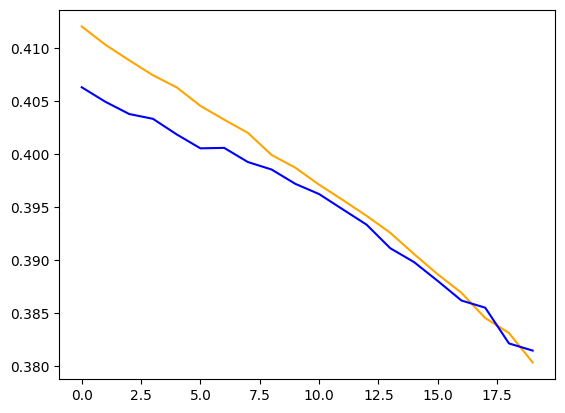

In [56]:

plt.plot(history.history['loss'], 'orange')
plt.plot(history.history['val_loss'], 'blue')